# Laboratorio 4

In [1]:

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import openeo

### Ejercicio 1 

Establezca una conexión con la api de sentinel 2, puede usar para eso el módulo openeo.


In [2]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


### Ejercicio 2

Descarga los .tif de cada uno de los lagos usando para eso las coordenadas o el geojson provisto


In [3]:
import json

with open("./archive/Lago_Amatitlan.geojson", "r", encoding="utf-8") as archivo:
    amatitlan = json.load(archivo)

with open("./archive/Lago_Atitlan.geojson", "r", encoding="utf-8") as archivo:
    atitlan = json.load(archivo)


print("Amatitlan, ", amatitlan)
print("Atitlan, ", atitlan)

Amatitlan,  {'type': 'FeatureCollection', 'name': 'Lago_Amatitlan', 'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}, 'features': [{'type': 'Feature', 'properties': {'name': 'Lago Amatitlán'}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-90.512924, 14.412347], [-90.512924, 14.493799], [-90.638065, 14.493799], [-90.638065, 14.412347], [-90.512924, 14.412347]]]}}]}
Atitlan,  {'type': 'FeatureCollection', 'name': 'Lago_Atitlan', 'crs': {'type': 'name', 'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}}, 'features': [{'type': 'Feature', 'properties': {'name': 'Lago Atitlán'}, 'geometry': {'type': 'Polygon', 'coordinates': [[[-91.07151, 14.5948], [-91.07151, 14.750979], [-91.326256, 14.750979], [-91.326256, 14.5948], [-91.07151, 14.5948]]]}}]}


In [4]:
geometry_atl = atitlan["features"][0]["geometry"]["coordinates"][0]

longitudes_atl = [punto[0] for punto in geometry_atl]
latitudes_atl = [punto[1] for punto in geometry_atl]

crd_atl = {
  "west": min(longitudes_atl),
    "east": max(longitudes_atl),
    "south": min(latitudes_atl),
    "north": max(latitudes_atl)
}

  

Cargando los datos en cubes

In [5]:

atitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=crd_atl,
    temporal_extent=["2025-01-01", "2025-08-01"],
    bands=["B02","B03","B04", "B08"]
)

In [ ]:
# Carga todo el rango
atitlan_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=crd_atl,
    temporal_extent=["2025-03-01", "2025-08-31"],
    bands=["B02","B03","B04","B08"]
)

# Luego filtras para quedarte con 2 imágenes por mes:
def select_two_per_month(cube):
    selected = []
    times = cube.time.to_index()  # o la forma que tenga para fechas
    for month in range(3, 9):
        month_dates = [t for t in times if t.month == month]
        # Escoge 2 fechas arbitrarias, por ejemplo las primeras 2 disponibles
        selected_dates = month_dates[:2]
        selected.extend(selected_dates)
    # Filtra el cube con estas fechas
    return cube.sel(time=selected)
print(atitlan_cube.dims)
print(atitlan_cube.coords)

atitlan_cube_filtered = select_two_per_month(atitlan_cube)


AttributeError: 'DataCube' object has no attribute 'dims'

In [ ]:
result_graph = atitlan_cube_filtered.save_result(format="GTIFF")
job = connection.create_job(result_graph)

# Iniciar y esperar que termine
job.start_and_wait()

# Obtener resultados y descargarlos a carpeta
results = job.get_results()
results.download_files("./data/GIS/")

print("Descarga finalizada.")

# Verificar archivos descargados
import os

folder = "./data/GIS/"
files = os.listdir(folder)
for f in files:
    size = os.path.getsize(os.path.join(folder, f))
    print(f"{f} - {size} bytes")

# Imprimir logs del job por si hubo errores
print("\nLogs del job:")
print(job.get_log())


0:00:00 Job 'j-2508072241104717b7906a97362ba7f9': send 'start'
0:00:13 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:18 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:24 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:32 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:43 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:00:55 Job 'j-2508072241104717b7906a97362ba7f9': created (progress 0%)
0:01:11 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:01:30 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:01:54 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:02:24 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:03:02 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:03:48 Job 'j-2508072241104717b7906a97362ba7f9': running (progress N/A)
0:04:47 Job 'j-2508072241104717b7906a97362ba7f9': running (progress

KeyboardInterrupt: 

In [9]:
import os
import re
from pathlib import Path
import numpy as np
import rasterio

# Carpeta de entrada
DATA_DIR = "./Atitlan/Atitlan"

clear_dates = {
    "2025-02-07", "2025-02-10", "2025-02-25", "2025-02-27",
    "2025-03-02", "2025-03-04", "2025-03-07", "2025-03-09",
    "2025-03-12", "2025-03-14", "2025-03-19", "2025-03-22",
    "2025-03-24", "2025-03-26", "2025-04-03", "2025-04-11",
    "2025-04-13", "2025-04-15", "2025-04-16", "2025-04-18",
    "2025-04-28", "2025-05-03", "2025-05-13", "2025-05-28",
    "2025-07-10", "2025-07-17", "2025-07-20", "2025-07-24",
    "2025-08-01"
}

# Diccionarios para guardar en memoria
ndvi_data = {}
ndwi_data = {}

def parse_date_from_name(name):
    m = re.search(r"openEO_(\d{4}-\d{2}-\d{2})Z", name)
    return m.group(1) if m else None

def compute_index(num, den):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den == 0, np.nan, num / den)

def normalize_if_needed(x):
    x = x.astype(np.float32)
    return x / 10000.0 if np.nanmax(x) > 2 else x

# Procesar todos los .tif
for tif_path in Path(DATA_DIR).glob("openEO_*Z*.tif"):
    fname = tif_path.name
    date = parse_date_from_name(fname)
    if not date or date not in clear_dates:
        continue

    with rasterio.open(tif_path) as src:
        # Suponiendo que las bandas están en orden: B03 (Green), B04 (Red), B08 (NIR), B11 (SWIR)
        green = normalize_if_needed(src.read(1))
        red   = normalize_if_needed(src.read(2))
        nir   = normalize_if_needed(src.read(3))
        swir  = normalize_if_needed(src.read(4))

        # Calcular índices
        ndvi = compute_index(nir - red, nir + red)
        ndwi = compute_index(green - nir, green + nir)  # McFeeters

        # Guardar en memoria
        ndvi_data[date] = ndvi
        ndwi_data[date] = ndwi

print(f"NDVI calculado para {len(ndvi_data)} fechas")
print(f"NDWI calculado para {len(ndwi_data)} fechas")

# Ejemplo de uso: acceder al NDVI de una fecha
example_date = "2025-03-12"
if example_date in ndvi_data:
    print(f"NDVI {example_date} shape:", ndvi_data[example_date].shape)




NDVI calculado para 28 fechas
NDWI calculado para 28 fechas
NDVI 2025-03-12 shape: (1751, 2759)


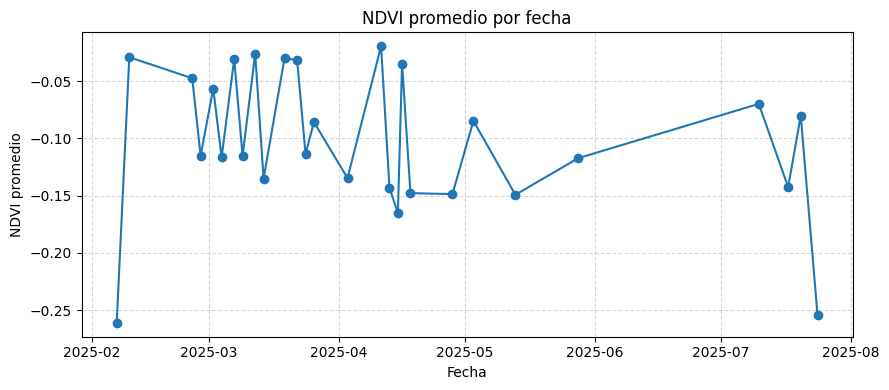

Listo: ndvi_mean_timeseries.csv y ndvi_mean_timeseries.png generados.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Promedio por fecha (ignora NaN) ---
def mean_by_date(index_dict):
    # index_dict: {"YYYY-MM-DD": ndarray2D, ...}
    rows = []
    for d, arr in index_dict.items():
        # (Opcional) limitar a rango válido del índice para evitar outliers raros
        arr_clip = np.clip(arr, -1.0, 1.0)
        rows.append({"date": pd.to_datetime(d), "mean": np.nanmean(arr_clip)})
    df = pd.DataFrame(rows).sort_values("date").set_index("date")
    return df

ndvi_series = mean_by_date(ndvi_data)

# Si también quieres NDWI:
# ndwi_series = mean_by_date(ndwi_data)

# --- 2) Guardar a CSV ---
ndvi_series.to_csv("ndvi_mean_timeseries.csv")  # columnas: date,mean

# --- 3) Graficar ---
plt.figure(figsize=(9,4))
plt.plot(ndvi_series.index, ndvi_series["mean"], marker="o")
plt.title("NDVI promedio por fecha")
plt.xlabel("Fecha")
plt.ylabel("NDVI promedio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("ndvi_mean_timeseries.png", dpi=150)
plt.show()

print("Listo: ndvi_mean_timeseries.csv y ndvi_mean_timeseries.png generados.")
